In [122]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from os import listdir
from numpy import asarray
from numpy import save
import tensorflow as tf
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from tensorflow import keras
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.metrics import classification_report
import datetime
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [123]:
df = pd.read_csv("wildfire_multi_region_dataset.csv")

df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        15500 non-null  float64
 1   longitude       15500 non-null  float64
 2   acq_date        15500 non-null  object 
 3   acq_time        15500 non-null  int64  
 4   year            15500 non-null  int64  
 5   month           15500 non-null  int64  
 6   season          15500 non-null  object 
 7   daynight        15500 non-null  object 
 8   region          15500 non-null  object 
 9   country         15500 non-null  object 
 10  fire_type       15500 non-null  object 
 11  satellite       15500 non-null  object 
 12  instrument      15500 non-null  object 
 13  brightness_k    15500 non-null  float64
 14  frp_mw          15500 non-null  float64
 15  fire_intensity  15500 non-null  object 
 16  confidence      15500 non-null  object 
 17  temp_max_c      15500 non-null 

In [125]:
df.isnull().sum()

latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
frp_mw            0
fire_intensity    0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
dtype: int64

In [126]:
df.describe()

,latitude,longitude,acq_time,year,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000
mean,10.251489,29.204768,1177.268645,2024.503032,7.244774,336.501241,80.181982,35.099335,17.783774,2.595579,38.136716
std,24.367098,78.693275,689.540417,0.500007,2.768195,19.209340,150.411669,5.850954,17.617369,3.154769,18.890952
min,-42.990800,-167.990600,0.000000,2024.000000,1.000000,290.000000,0.370000,12.800000,0.000000,0.000000,5.000000
25%,-7.561575,-41.641000,600.000000,2024.000000,5.000000,324.570000,15.010000,31.000000,5.100000,0.610000,24.300000
50%,10.477350,34.807950,1200.000000,2025.000000,8.000000,335.170000,35.445000,35.200000,12.500000,1.520000,36.300000
75%,30.104450,95.064200,1756.000000,2025.000000,9.000000,346.670000,83.720000,39.200000,24.700000,3.330000,50.800000
max,69.982600,153.987500,2359.000000,2025.000000,12.000000,574.860000,3000.000000,55.500000,188.800000,34.440000,95.000000


In [127]:
df.shape

(15500, 21)

In [128]:
columnas_cat = df.select_dtypes(include=['object', 'category']).columns

for col in columnas_cat:
    print(f"Valores únicos en {col}:")
    print(df[col].unique())
    print("-" * 20)


Valores únicos en acq_date:
['2024-01-01' '2024-01-02' '2024-01-03' '2024-01-04' '2024-01-05'
 '2024-01-06' '2024-01-07' '2024-01-08' '2024-01-09' '2024-01-10'
 '2024-01-11' '2024-01-12' '2024-01-13' '2024-01-14' '2024-01-15'
 '2024-01-16' '2024-01-17' '2024-01-18' '2024-01-19' '2024-01-20'
 '2024-01-21' '2024-01-22' '2024-01-23' '2024-01-24' '2024-01-25'
 '2024-01-26' '2024-01-27' '2024-01-28' '2024-01-29' '2024-01-30'
 '2024-01-31' '2024-02-01' '2024-02-02' '2024-02-03' '2024-02-04'
 '2024-02-05' '2024-02-06' '2024-02-07' '2024-02-08' '2024-02-09'
 '2024-02-10' '2024-02-11' '2024-02-12' '2024-02-13' '2024-02-15'
 '2024-02-16' '2024-02-17' '2024-02-18' '2024-02-19' '2024-02-20'
 '2024-02-21' '2024-02-22' '2024-02-23' '2024-02-24' '2024-02-25'
 '2024-02-26' '2024-02-27' '2024-02-28' '2024-02-29' '2024-11-01'
 '2024-11-02' '2024-11-03' '2024-11-05' '2024-11-06' '2024-11-07'
 '2024-11-08' '2024-11-09' '2024-11-10' '2024-11-11' '2024-11-12'
 '2024-11-13' '2024-11-14' '2024-11-15' '2024-11

In [129]:
columnas_num = df.select_dtypes(include=['float64', 'int64']).columns

for col in columnas_num:
    print(f"Valores únicos en {col}:")
    print(df[col].unique())
    print("-" * 20)

Valores únicos en latitude:
[-16.7722 -41.196  -39.875  ...  -3.772    6.5688 -27.7634]
--------------------
Valores únicos en longitude:
[151.0241 130.1397 124.9104 ... -16.7081 -12.5954  44.2033]
--------------------
Valores únicos en acq_time:
[1133 1251 1326 ... 1408 1605 1016]
--------------------
Valores únicos en year:
[2024 2025]
--------------------
Valores únicos en month:
[ 1  2 11 12  6  7  8  9  3 10  4  5]
--------------------
Valores únicos en brightness_k:
[347.72 357.82 333.76 ... 377.47 297.73 356.97]
--------------------
Valores únicos en frp_mw:
[29.38 62.05  3.35 ... 64.84 78.96 68.71]
--------------------
Valores únicos en temp_max_c:
[42.1 43.8 35.4 39.6 46.7 45.4 42.3 46.8 35.  40.7 38.2 33.4 47.3 39.2
 40.9 41.9 38.8 47.1 46.  43.6 34.2 38.6 42.  41.4 39.1 33.5 35.8 36.
 36.1 39.5 33.9 40.2 41.1 38.4 40.6 37.9 37.  43.1 38.9 40.3 51.9 36.6
 42.5 41.  37.8 41.3 43.7 43.  49.6 35.7 46.2 41.7 38.  43.9 38.1 45.9
 31.6 32.2 35.6 43.2 37.6 45.1 30.5 36.8 36.9 38.3 3

In [130]:
columnas_a_borrar = [
    "acq_date",    # Ya tengo month y season 
    "satellite",   # Tecnología del sensor (no influye en el fuego)
    "instrument",  # Tecnología del sensor
    "country",     # Tengo la columna region que son 7
    "acq_time",    # La hora exacta puede ser muy ruidosa
    "year",        # Solo hay datos de 2024, 2025
    "latitude",    # Muy concreto, eliminarmos para evitar que memorice
    "longitude"    # Muy concreto, eliminarmos para evitar que memorice
]

df = df.drop(columns=columnas_a_borrar)

In [131]:
# Variables a escoger con las que voy a trabajar 
# Temperatura maxima, velocidad del viento maxima y precipitación.

variables = df[["temp_max_c", "wind_max_kmh", "precip_mm"]]

variables.head()



,temp_max_c,wind_max_kmh,precip_mm
0,42.1,1.7,0.47
1,43.8,2.2,0.27
2,35.4,4.4,0.35
3,39.6,34.7,0.30
4,46.7,16.7,6.49


  fire_intensity  count
0       Moderate   6861
1           High   4785
2            Low   2493
3        Extreme   1361


<Axes: xlabel='fire_intensity'>

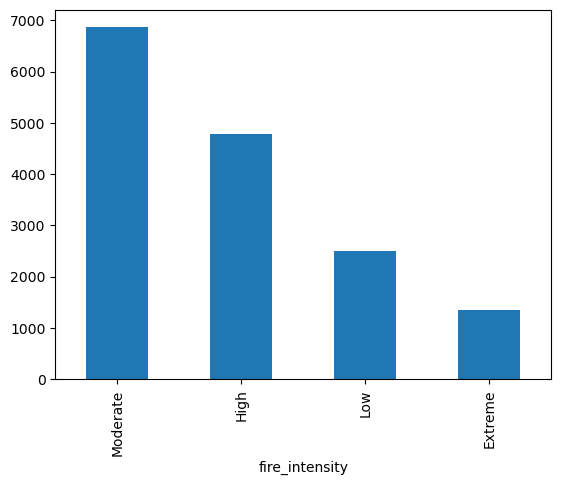

In [132]:
#Se observa un fuerte desbalance de clases. Esto implica que la Matriz de Confusión podría mostrar una alta precisión en la clase 'Low', pero debemos vigilar de cerca la clase 'Extreme',
#ya que el modelo tendrá menos ejemplos para aprender a identificarla
tabla_distribucion = df['fire_intensity'].value_counts().reset_index()
print(tabla_distribucion)
df['fire_intensity'].value_counts().plot(kind='bar')

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           15500 non-null  int64  
 1   season          15500 non-null  object 
 2   daynight        15500 non-null  object 
 3   region          15500 non-null  object 
 4   fire_type       15500 non-null  object 
 5   brightness_k    15500 non-null  float64
 6   frp_mw          15500 non-null  float64
 7   fire_intensity  15500 non-null  object 
 8   confidence      15500 non-null  object 
 9   temp_max_c      15500 non-null  float64
 10  wind_max_kmh    15500 non-null  float64
 11  precip_mm       15500 non-null  float64
 12  humidity_pct    15500 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 1.5+ MB


In [134]:
cols_to_dummies = ['season', 'daynight', 'region', 'fire_type', 'confidence']
df = pd.get_dummies(df, columns=cols_to_dummies, drop_first=True, dtype=int)

In [135]:
mapeo_intensidad = {
    'Low': 1,
    'Moderate': 2,
    'High': 3,
    'Extreme': 4
}

df['fire_intensity_num'] = df['fire_intensity'].replace(mapeo_intensidad)

/tmp/ipykernel_23432/2471048767.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fire_intensity_num'] = df['fire_intensity'].replace(mapeo_intensidad)


In [136]:
df = df.drop(columns=["fire_intensity"])

In [137]:
df.shape

(15500, 29)

In [138]:
X = variables
y = df['fire_intensity_num'].to_frame()

In [139]:
df.head()

,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,season_Spring,season_Summer,season_Winter,...,fire_type_Forest,fire_type_Grassland,fire_type_Peatland,fire_type_Prescribed,fire_type_Savanna,fire_type_Shrubland,fire_type_Wildfire,confidence_low,confidence_nominal,fire_intensity_num
0,1,347.72,29.38,42.1,1.7,0.47,18.4,0,1,0,...,1,0,0,0,0,0,0,0,0,2
1,1,357.82,62.05,43.8,2.2,0.27,11.7,0,1,0,...,0,0,0,0,0,0,0,0,1,3
2,1,333.76,3.35,35.4,4.4,0.35,5.0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
3,1,323.94,46.35,39.6,34.7,0.30,39.1,0,1,0,...,1,0,0,0,0,0,0,0,0,2
4,1,359.59,434.80,46.7,16.7,6.49,53.1,0,1,0,...,1,0,0,0,0,0,0,0,0,4


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      15500 non-null  int64  
 1   brightness_k               15500 non-null  float64
 2   frp_mw                     15500 non-null  float64
 3   temp_max_c                 15500 non-null  float64
 4   wind_max_kmh               15500 non-null  float64
 5   precip_mm                  15500 non-null  float64
 6   humidity_pct               15500 non-null  float64
 7   season_Spring              15500 non-null  int64  
 8   season_Summer              15500 non-null  int64  
 9   season_Winter              15500 non-null  int64  
 10  daynight_N                 15500 non-null  int64  
 11  region_Mediterranean       15500 non-null  int64  
 12  region_North_America       15500 non-null  int64  
 13  region_South_America       15500 non-null  int

In [141]:
df.corr()["fire_intensity_num"].abs().sort_values(ascending=False)[1:]

frp_mw                       0.617168
brightness_k                 0.389802
region_South_Asia            0.244512
humidity_pct                 0.161072
region_South_America         0.140744
region_North_America         0.129648
season_Summer                0.121395
temp_max_c                   0.105495
season_Spring                0.086788
region_Southeast_Asia        0.083774
fire_type_Grassland          0.073019
fire_type_Wildfire           0.069342
region_Mediterranean         0.067517
fire_type_Prescribed         0.063536
month                        0.060776
precip_mm                    0.060438
fire_type_Savanna            0.057563
fire_type_Peatland           0.052335
fire_type_Bushfire           0.047293
fire_type_Shrubland          0.042146
fire_type_Deforestation      0.031093
season_Winter                0.014874
region_Sub_Saharan_Africa    0.009889
confidence_low               0.009136
fire_type_Forest             0.009081
confidence_nominal           0.001243
daynight_N  

Pruebo con todas las columnas en vez de solamente con 3.

In [168]:
X = df.drop(['fire_intensity_num'], axis = 1)
y = df['fire_intensity_num'].to_frame()

In [169]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y,test_size=0.1,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full,y_train_full,test_size=0.1,random_state=42)

In [170]:
X_train.shape[1:]

(28,)

In [171]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.fit_transform(X)

In [172]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=1000, max_depth=20, class_weight='balanced', random_state=42)
rnd_clf.fit(X_train,y_train)

/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [173]:
y_pred = rnd_clf.predict(X_test)

In [174]:
accuracy_score(y_test,y_pred)

0.9980645161290322

In [175]:
svm_lineal = SVC(kernel="linear", C=2.0, random_state=42) 
svm_lineal.fit(X_train_scaled, y_train)

/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [176]:
pred_lineal = svm_lineal.predict(X_test_scaled)

print("=== SVM LINEAL ===")
print("Accuracy:", accuracy_score(y_test, pred_lineal)) 

=== SVM LINEAL ===
Accuracy: 0.9838709677419355


In [142]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y,test_size=0.1,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full,y_train_full,test_size=0.1,random_state=42)

In [143]:
X_train.shape[1:]

(3,)

In [144]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.fit_transform(X)

Random Forest con class_weight='balanced' 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=1000, max_depth=20, class_weight='balanced', random_state=42)
rnd_clf.fit(X_train,y_train)

/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [146]:
y_pred = rnd_clf.predict(X_test)

In [147]:
accuracy_score(y_test,y_pred)

0.36838709677419357

Random Forest sin class_weight='balanced' 

In [148]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf_prueba = RandomForestClassifier(n_estimators=1000, max_depth=20, random_state=42)
rnd_clf_prueba.fit(X_train,y_train)

/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [149]:
y_pred_prueba = rnd_clf_prueba.predict(X_test)

In [150]:
accuracy_score(y_test,y_pred_prueba)

0.39225806451612905

SVC Lineal

In [151]:
svm_lineal = SVC(kernel="linear", C=2.0, random_state=42) 
svm_lineal.fit(X_train_scaled, y_train)

/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [152]:
pred_lineal = svm_lineal.predict(X_test_scaled)

print("=== SVM LINEAL ===")
print("Accuracy:", accuracy_score(y_test, pred_lineal)) 

=== SVM LINEAL ===
Accuracy: 0.4290322580645161


In [153]:
svm_lineal_prueba = SVC(kernel="linear", C=2.0, class_weight='balanced', random_state=42) # He probado añadiendo class_weight='balanced' y me da de accuracy 0.16
svm_lineal_prueba.fit(X_train_scaled, y_train)

/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [154]:
# Predicción con class_weight='balanced'
pred_lineal_prueba = svm_lineal_prueba.predict(X_test_scaled)

print("=== SVM LINEAL ===")
print("Accuracy:", accuracy_score(y_test, pred_lineal_prueba)) 


=== SVM LINEAL ===
Accuracy: 0.16129032258064516


Clasificación Report de SVM Lineal

In [158]:
from sklearn.metrics import classification_report

# Esto te genera las métricas macro, micro y weighted que pide el índice del trabajo
print(classification_report(y_test, pred_lineal, target_names=['Low', 'Moderate', 'High', 'Extreme']))

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       261
    Moderate       0.43      1.00      0.60       665
        High       0.00      0.00      0.00       490
     Extreme       0.00      0.00      0.00       134

    accuracy                           0.43      1550
   macro avg       0.11      0.25      0.15      1550
weighted avg       0.18      0.43      0.26      1550



/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

Clasificación Report de Random Forest

In [159]:
from sklearn.metrics import classification_report

# Esto te genera las métricas macro, micro y weighted que pide el índice del trabajo
print(classification_report(y_test, y_pred, target_names=['Low', 'Moderate', 'High', 'Extreme']))

              precision    recall  f1-score   support

         Low       0.11      0.05      0.07       261
    Moderate       0.43      0.62      0.50       665
        High       0.32      0.30      0.31       490
     Extreme       0.12      0.04      0.06       134

    accuracy                           0.37      1550
   macro avg       0.25      0.25      0.23      1550
weighted avg       0.32      0.37      0.33      1550



Matriz de Confusión: SVM Lineal

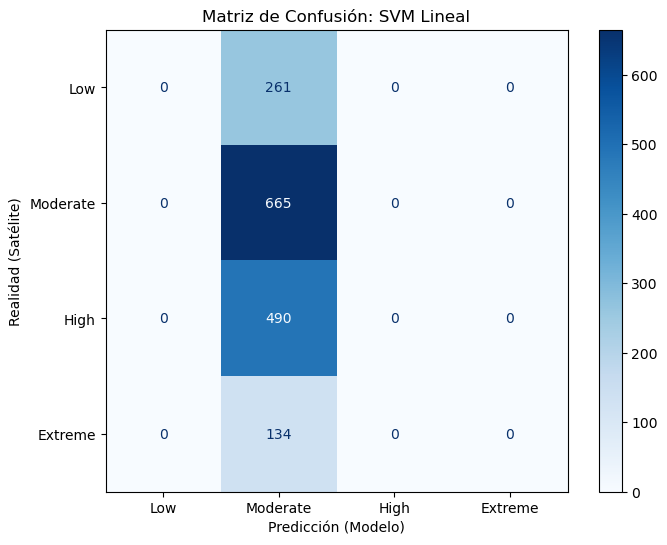

In [155]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lineal = confusion_matrix(y_test, pred_lineal)

# 4. Visualización
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lineal, 
                              display_labels=['Low', 'Moderate', 'High', 'Extreme'])

# Usamos un mapa de colores profesional (Blues o Greens)
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_title('Matriz de Confusión: SVM Lineal')
ax.set_xlabel('Predicción (Modelo)')
ax.set_ylabel('Realidad (Satélite)')

plt.show()

Matriz de Confusión: Random Forest con class_weight='balanced'

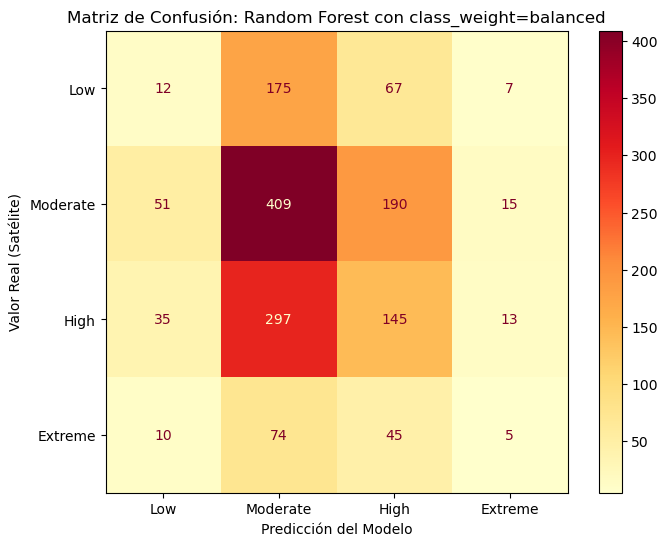

In [156]:
# 1. Generamos la matriz con las predicciones del Random Forest balanceado
cm_rf = confusion_matrix(y_test, y_pred)

# 2. Configuramos la visualización
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, 
                              display_labels=['Low', 'Moderate', 'High', 'Extreme'])

# 3. Dibujamos
disp.plot(cmap='YlOrRd', ax=ax, values_format='d') 

ax.set_title('Matriz de Confusión: Random Forest con class_weight=balanced')
ax.set_xlabel('Predicción del Modelo')
ax.set_ylabel('Valor Real (Satélite)')

plt.show()

Matriz de Confusión: Random Forest sin  class_weight='balanced'

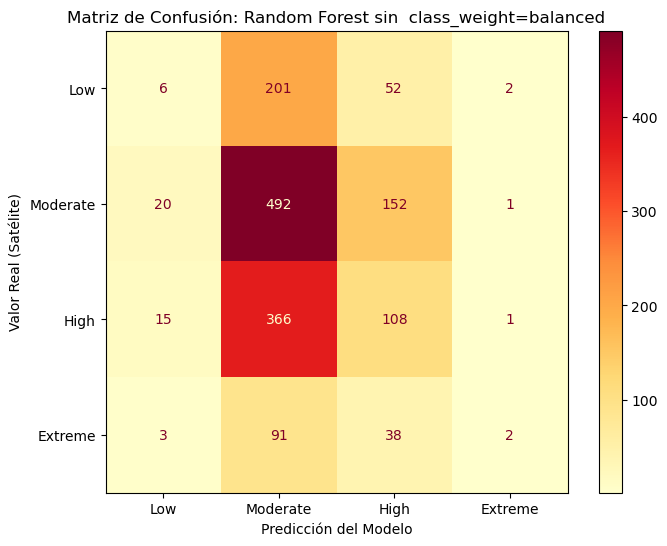

In [157]:
# 1. Generamos la matriz con las predicciones del Random Forest balanceado
cm_rf = confusion_matrix(y_test, y_pred_prueba)

# 2. Configuramos la visualización
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, 
                              display_labels=['Low', 'Moderate', 'High', 'Extreme'])

# 3. Dibujamos
disp.plot(cmap='YlOrRd', ax=ax, values_format='d') 

ax.set_title('Matriz de Confusión: Random Forest sin  class_weight=balanced')
ax.set_xlabel('Predicción del Modelo')
ax.set_ylabel('Valor Real (Satélite)')

plt.show()